# Chapter 2. 지도 학습

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import scipy as sp
import IPython
import sklearn
import mglearn

print('Python 버전:', sys.version)
print('numpy 버전:', np.__version__)
print('pandas 버전:', pd.__version__)
print('matplotlib 버전:', matplotlib.__version__)

print('SciFy 버전:', sp.__version__)
print('IPython 버전:', IPython.__version__)
print('scikit-learn 버전:', sklearn.__version__)

from sklearn.model_selection import train_test_split
#plt.rc('font', family="Apple SD Gothic Neo")

Python 버전: 3.11.5 (main, Sep 11 2023, 13:54:46) [GCC 11.2.0]
numpy 버전: 1.24.3
pandas 버전: 2.0.3
matplotlib 버전: 3.7.2
SciFy 버전: 1.11.1
IPython 버전: 8.15.0
scikit-learn 버전: 1.3.0


## 2.3 지도 학습 알고리즘

### 2.3.8 커널 서포트 벡터 머신
- 커널 서포트 벡터 머신은 ***입력 데이터에서 단순한 초평면(hyperplane)으로 정의되지 않는 더 복잡한 모델을 만들수 있도록 확장***
- 분류와 회귀 모두에서 사용 가능, **매개변수 설정과 데이터 스케일에 매우 민감 -> 입력 특성의 범위가 비슷해야함 -> 스케일링 필요**

- **장단점**
> - **데이터의 특성이 적더라도 복잡한 결정 경계 생성 가능 ~ 다양한 데이터셋에서 잘 작동**
> - 데이터 포인트가 많을 경우(100,000개) 속도와 메모리 관점에서 도전적인 알고리즘
> - **데이터 전처리와 매개변수 설정에 신경을 많이 써야하고 결과 분석하기가 용이하지 않음**

- **매개변수**
> - **커널 SVM에서 중요한 매개변수는 규제 매개변수 C이고, 어떤 커널을 사용할지와 각 커널에 따른 매개변수**
> - 커널 매개변수 옵션은 **'linear'(x1.x2), 'poly'((gamma(x1.x2)+c)^d), 'rbf', 'sigmoid'(tanh(gamma(x1.x2)+c), 'precomputed'**
> - c는 coef0, d는 degree 매개변수에서 지정, **커널 매개변수의 기본값은 'rbf'이고** 'precomputed'는 미리 계산된 거리 값을 입력 특성으로 사용
> - RBF 커널
>> - 가우시안 커널 폭의 역수인 gamma 매개변수 하나를 가짐
>> - gamma와 C 모두 모델의 복잡도를 조정하며 둘 다 큰 값이 더 복잡한 모델을 만듦
>> - **gamma와 C를 함께 조정하는 것을 추천함**

#### <U>*선형 모델과 비선형 특성*</U>
- 직선과 초평면은 유연하지 못하여 저차원 데이터셋에서는 선형 모델이 매우 제한적
- 선형 모델을 유연하게 만드는 한 가지 방법은 **특성끼리 곱하거나 특성을 거듭제곱하는 식으로 새로운 특성을 추가하는 것임**

In [2]:
from sklearn.datasets import make_blobs
X, y = make_blobs(centers=4, random_state=8)
y = y % 2

Text(0, 0.5, 'Feature 1')

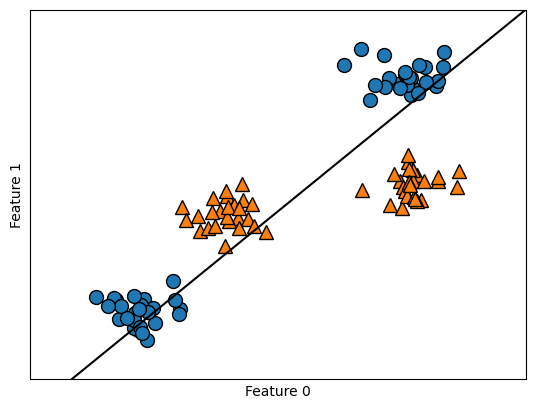

In [3]:
# 분류를 위한 선형 모델은 직선으로만 데이터 포인트를 나눌 수 있어서 해당 데이터에 잘 들어 맞지 않음
from sklearn.svm import LinearSVC
linear_svm = LinearSVC(max_iter=5000, tol=1e-3).fit(X,y)

mglearn.plots.plot_2d_separator(linear_svm, X)
mglearn.discrete_scatter(X[:,0], X[:,1], y)
plt.xlabel('Feature 0')
plt.ylabel('Feature 1')

Text(0.5, 0, 'Feature 1 ** 2')

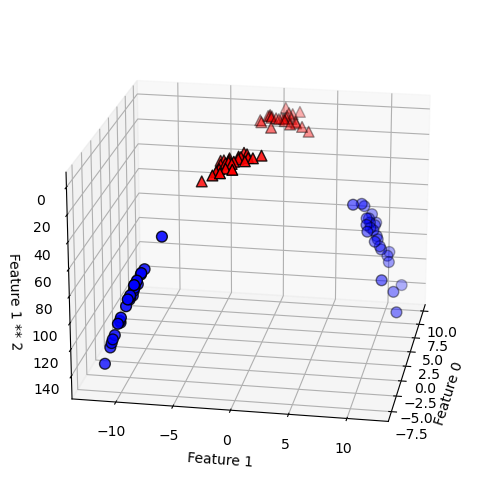

In [4]:
# 두 번째 특성을 제곱한 특성1**2를 새로운 특성으로 추가해 입력 특성을 확장한 케이스
X_new = np.hstack([X, X[:, 1:]**2])
from mpl_toolkits.mplot3d import Axes3D, axes3d
figure = plt.figure()

# 3차원 그래프
#if matplotlib.__version__ >= '3.4':
    #ax = Axes3D(figure, elev=-152, azim=-26, auto_add_to_figure=False)
    #figure.add_axes(ax)
#else:
    #ax = Axes3D(figure, elev=-152, azim=-26)

ax = Axes3D(figure, elev=-160, azim=-10, auto_add_to_figure=False)
figure.add_axes(ax)

# y==0인 포인트를 먼저 그리고 그 다름 y==1인 포인트를 그림
mask = y == 0
ax.scatter(X_new[mask, 0], X_new[mask, 1], X_new[mask, 2], c='b',
           s=60, edgecolor='k')
ax.scatter(X_new[~mask, 0], X_new[~mask, 1], X_new[~mask, 2], c='r', marker='^',
           s=60, edgecolor='k')
ax.set_xlabel('Feature 0')
ax.set_ylabel('Feature 1')
ax.set_zlabel('Feature 1 ** 2')

Text(0.5, 0, 'Feature 1**2')

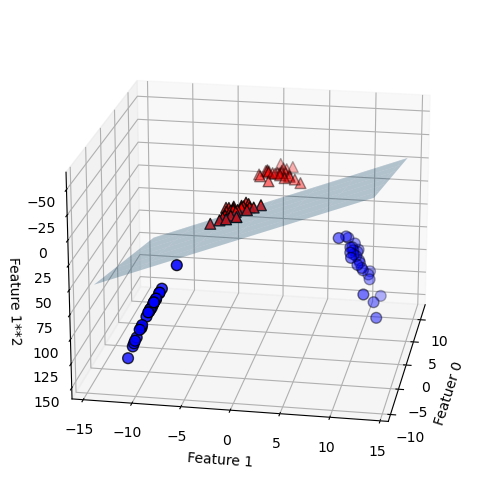

In [5]:
# 새로운 데이터셋에서는 선형 모델과 3차원 공간의 평면을 사용해 두 클래스 분류가 가능
linear_svm_3d = LinearSVC(max_iter=5000).fit(X_new, y)
coef, intercept = linear_svm_3d.coef_.ravel(), linear_svm_3d.intercept_

# 선형 결정 경계 그리기
figure = plt.figure()
ax = Axes3D(figure, elev=-160, azim=-10, auto_add_to_figure=False)
figure.add_axes(ax)

xx = np.linspace(X_new[:,0].min()-2, X_new[:,0].max()+2, 50)
yy = np.linspace(X_new[:,1].min()-2, X_new[:,1].max()+2, 50)

XX, YY = np.meshgrid(xx,yy)
ZZ = (coef[0]*XX + coef[1]*YY + intercept) / -coef[2]
ax.plot_surface(XX, YY, ZZ, rstride=8, cstride=8, alpha=0.3)

ax.scatter(X_new[mask, 0], X_new[mask, 1], X_new[mask, 2], c='b',
           s=60, edgecolor='k')
ax.scatter(X_new[~mask, 0], X_new[~mask, 1], X_new[~mask, 2], c='r', marker='^',
           s=60, edgecolor='k')

ax.set_xlabel('Featuer 0')
ax.set_ylabel('Feature 1')
ax.set_zlabel('Feature 1**2')

> - 원래 특성으로 (특성 0과 1만으로) 투영해보면 이 선형 SVM 모델은 더 이상 선형이 아님

Text(0, 0.5, 'Feature 1')

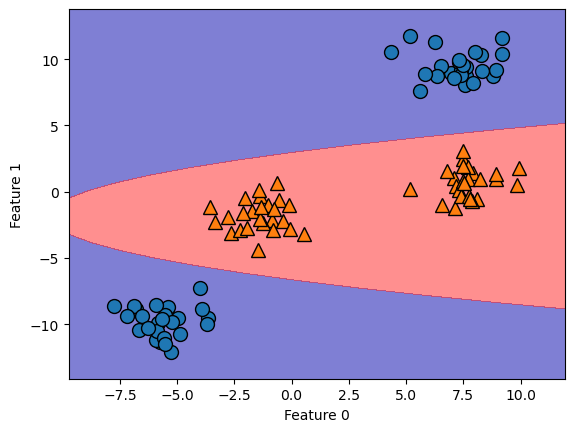

In [6]:
ZZ = YY**2
dec = linear_svm_3d.decision_function(np.c_[XX.ravel(), YY.ravel(), ZZ.ravel()])
plt.contourf(XX, YY, dec.reshape(XX.shape), levels=[dec.min(), 0, dec.max()],
             cmap=mglearn.cm2, alpha=0.5)
mglearn.discrete_scatter(X[:,0], X[:,1], y)
plt.xlabel('Feature 0')
plt.ylabel('Feature 1')

#### <U>*커널 기법 & SVM 이해하기*</U>
- 수학적 기교를 사용해 새로운 특성을 많이 만들지 않고서도 고차원에서 분류기를 학습시킴 -> **실제로 데이터를 확장하지 않고 확장된 특성에 대한 데이터 포인트들의 거리(정확히는 스칼라곱)을 계산**
- 데이터를 고차원 공간에 매핑하는 방법
> - 원래 특성의 가능한 조합을 지정된 차수까지 모두 계산하는 **다항식 커널**
> - **가우시안 커널**로도 불리우는 radial basis function(RBF) 커널
> - 가우시안 커널은 차원이 무한한 특성 공간에 매핑하는 것으로 **모든 차수의 모든 다항식을 고려, 하지만 특성의 중요도는 고차항이 될수록 감소**(지수함수의 테일러 급수 전개 사용)

- 일반적으로 훈련 데이터의 일부만 결정 경계를 만드는데 영향을 줌 -> **두 클래스 사이의 경계에 위치한 데이터 포인트, 이러한 데이터 포인트를 서포트 벡터라고 함**
- 학습이 진행되는 동안 SVM은 각 훈련 데이터 포인트가 두 클래스 사이의 결정 경계를 구분하는 데 얼마나 중요한지를 학습, **서포트 벡터의 중요도는 훈련 과정에서 학습하여 SVC 객체의 *dual_coef_* 속성에 저장**
- 새로운 데이터 포인트에 대해 예측하려면 각 서포트 벡터와의 거리를 측정, 분류 결정은 서포트 벡터까지의 거리에 기반 

> - 데이터 포인트 사이의 거리는 가우시안 커널에 의해 계산
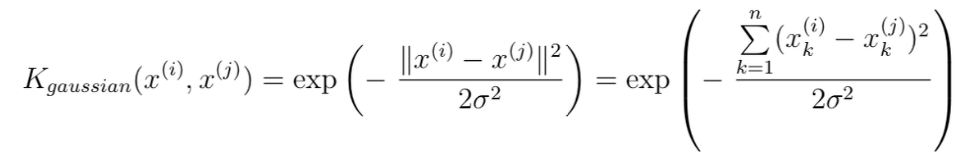
> - **x1과 x2는 데이터 포인트이며 ||x1-x2||는 유클리디안 거리이고 감마는 가우시안 커널의 폭을 제어하는 매개변수**(~ 1/(2*시그마^2)) 

Text(0, 0.5, 'Feature 1')

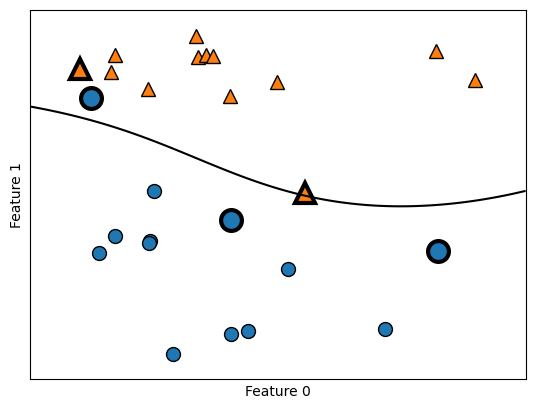

In [16]:
from sklearn.svm import SVC

X, y = mglearn.tools.make_handcrafted_dataset()
svm = SVC(kernel='rbf', C=10, gamma=0.1).fit(X, y)
mglearn.plots.plot_2d_separator(svm, X, eps=0.5)

# 데이터 포인트 그리기
mglearn.discrete_scatter(X[:,0], X[:,1], y)
# 서포트 벡터
sv = svm.support_vectors_
# dual_coef_의 부호에 의해 서포트 벡터의 클래스 레이블이 결정
sv_labels = svm.dual_coef_.ravel() > 0
mglearn.discrete_scatter(sv[:,0], sv[:,1], sv_labels, s=15, markeredgewidth=3)
plt.xlabel('Feature 0')
plt.ylabel('Feature 1')

#### <U>*SVM 매개변수 튜닝*</U>
- **감마 매개변수**는 가우시안 커널 폭의 역수에 해당하며, **하나의 훈련 샘플이 미치는 영향 범위를 결정**
> - 가우시안 커널의 반경이 클수록 훈련 샘플의 영향 범위도 증가
> - **작은 값은 넓은 영역을 뜻하며, 큰 값이라면 영향이 미치는 범위가 제한적**
> - **작은 감마 값이 결정 경계를 천천히 바뀌게 하므로 모델의 복잡도 감소, 큰 감마 값은 더 복잡한 모델 생성**
- **C 매개변수**는 선형 모델에서 사용한 것과 비슷한 **규제 매개변수**
> - **각 포인트의 중요도(정확히는 *dual_coef_* 값)를 제한** 
> - 작은 C는 매우 제약이 큰 모델을 만들고 각 데이터 포인트의 영향력이 작음, C를 증가시키면 포인트들이 모델에 큰 영향을 주며 복잡한 모델을 생성

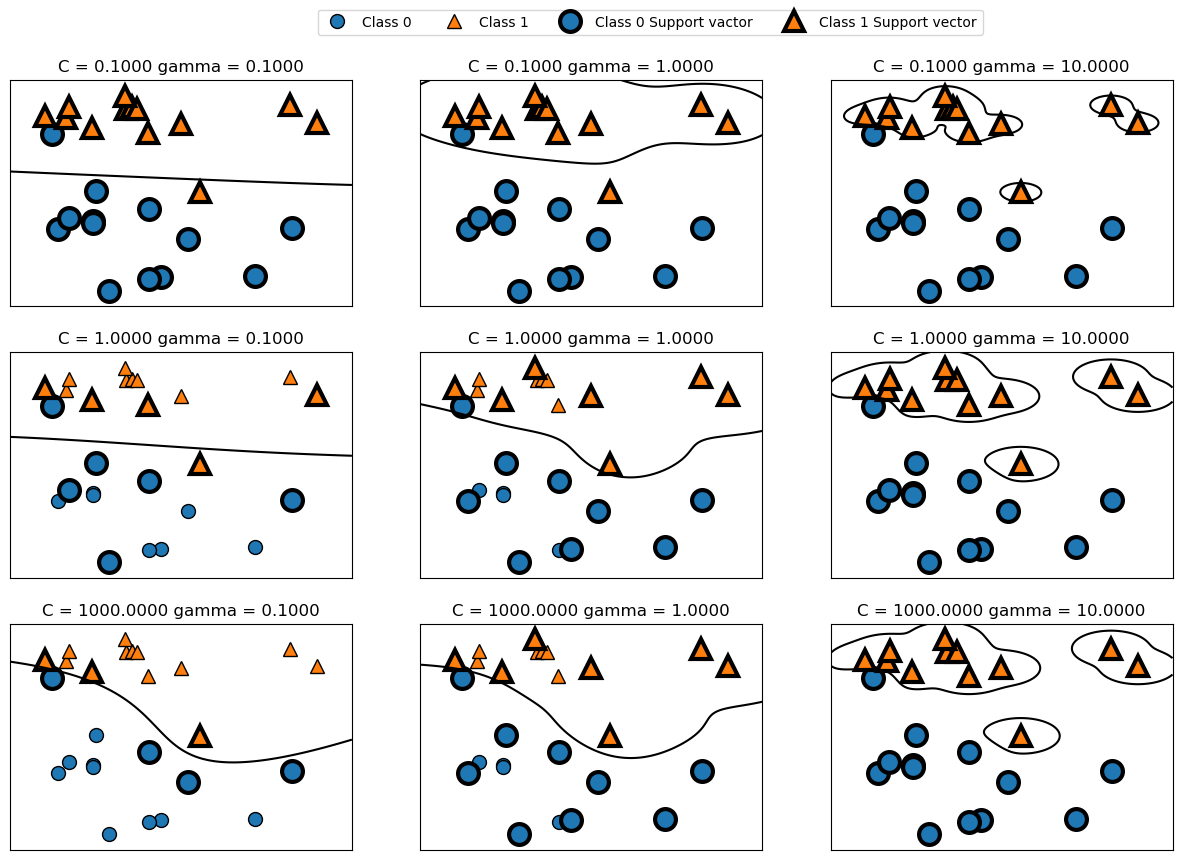

In [8]:
fig, axes = plt.subplots(3, 3, figsize=(15,10))

for ax, C in zip(axes, [-1, 0, 3]):
    for a, gamma in zip(ax, range(-1,2)):
        mglearn.plots.plot_svm(log_C=C, log_gamma=gamma, ax=a)

axes[0,0].legend(['Class 0','Class 1','Class 0 Support vactor','Class 1 Support vector'],
                 ncol=4, loc=(0.9, 1.2))

- **왼쪽에서 오른쪽으로 갈수록 감마 값 증가 -> 오른쪽으로 갈수록 결정 경계는 하나의 포인트에 더 민감**
- **위에서 아래로 내려올수록 C값 증가 -> 아래로 내려올수록 결정 경계를 휘어서 정확하게 분류하게 함** 

> - RBF 커널 SVM을 유방암 데이터셋에 적용, 기본값 C = 1, gamma = 1/n_features 사용

In [9]:
from sklearn.datasets import load_breast_cancer
cancer = load_breast_cancer()

X_train, X_test, y_train, y_test = train_test_split(cancer.data, cancer.target, random_state=0)

svc = SVC()
svc.fit(X_train, y_train)

print('훈련 세트 정확도:{:.2f}'.format(svc.score(X_train, y_train)))
print('테스트 세트 정확도:{:.2f}'.format(svc.score(X_test, y_test)))

훈련 세트 정확도:0.90
테스트 세트 정확도:0.94


#### <U>*SVM을 위한 데이터 전처리*</U>
- **스케일링(Scaling)**
    > - **모든 특성 값을 평균이 0이고 분산이 1이 되도록 변경 : 표준화 방법 중 *StandardScaler* 주로 사용**
    > - **0과 1사이에 위치하도록 데이터를 변경 : 정규화 방법 중 *MinMaxScaler* 주로 사용**

In [10]:
# 훈련 세트에서 특성별 최솟값 계산
min_on_training = X_train.min(axis=0)
# 훈련 세트에서 특성별 (최댓값 - 최솟값) 범위 계산
range_on_training = (X_train - min_on_training).max(axis=0)

# 훈련 데이터에 최솟값을 빼고 범위로 나누면 각 특성에 대해 최솟값은 0 최댓값은 1임
X_train_scaled = (X_train - min_on_training) / range_on_training

# 테스트 세트에도 같은 작업을 적용하지만 훈련 세트에서 계산한 최솟값과 범위를 사용
X_test_scaled = (X_test - min_on_training) / range_on_training

In [11]:
svc = SVC()
svc.fit(X_train_scaled, y_train)
print('훈련 세트 정확도:{:.2f}'.format(svc.score(X_train_scaled, y_train)))
print('테스트 세트 정확도:{:.2f}'.format(svc.score(X_test_scaled, y_test)))

훈련 세트 정확도:0.98
테스트 세트 정확도:0.97


### 2.3.9 신경망(딥러닝) 
- 복잡한 딥러닝 알고리즘의 출발점이며 비교적 간단하게 분류와 회귀에 쓸 수 있는 **다층 퍼셉트론(multilayer perceptron, MLP)**
- **scikit-learn에서는 합성곱 신경망(CNN)이나 순환 신경망(RNN)이 구현되어 있지 않음**
- 더 복잡하고 대규모인 모델을 만들려면 scikit-learn을 넘어서 **전문적인 딥러닝 라이브러리를 살펴보아야 함(keras, tensorflow)**
- 잘 알려진 딥러닝 라이브러리들은 모두 **scikit-learn에서는 지원하지 않는 기능인 고성능 그래칙 처리장치(GPU) 사용 가능**, GPU를 사용하면 10배에서 100배까지 빠르게 연산할 수 있어서 대규모 데이터셋을 사용한 딥러닝 분야에서 필수

#### <U>*신경망 모델*</U>
- MLP는 여러 단계를 거쳐 결정을 만들어내는 선형 모델의 일반화된 모습
- 여러개의 가중치 합을 계산하는 것은 수학적으로 하나의 가중치 합을 계산하는 것과 같으므로 **선형 모델모다 강력하게 만들려면 추가적인 기교 필요**
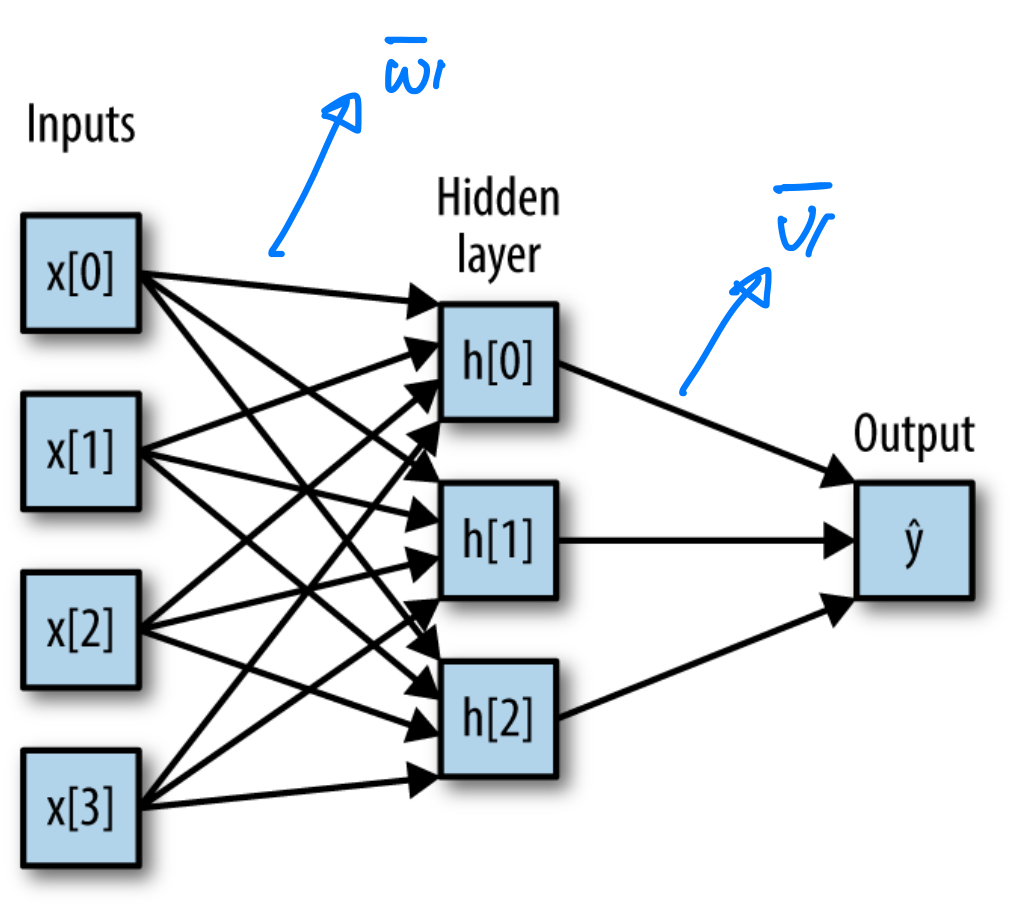
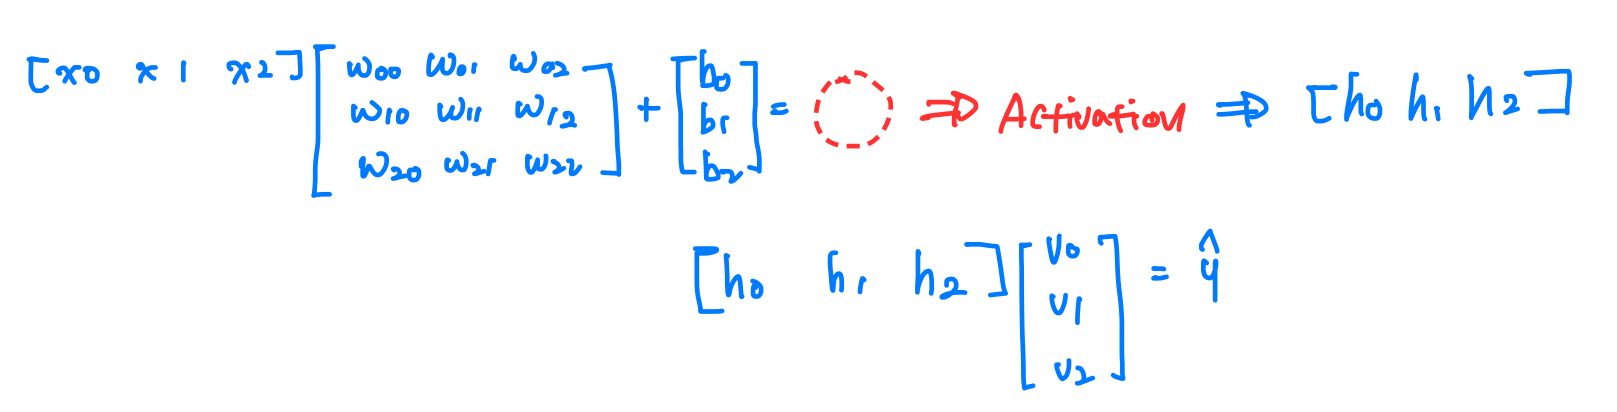
> - 각 은닉 유닛의 가중치 합을 계산한 후 그 결과에 비선형 함수인 렐루(rectified linear unit, relu)나 하이퍼볼릭 탄젠트(tanh)를 적용, 이 함수 결과의 가중치 합을 계산하여 출력 y를 도출
> - **relu 함수는 0이하를 잘라버리고, tanh 함수는 낮은 입력값에 대해서는 -1로 수렴하고 큰 입력값에 대해서는 +1로 수렴**
> - **보통 분류의 경우에는 신경망 마지막 출력층에 Sigmoid(이진분류)나 Softmax(다중분류) 함수를 적용하여 최종 출력 y을 계산**
- 신경망에서는 종종 편향 값 b를 그림에 생략하기도 하지만 MLP 혹은 피드 포워드 신경망에서는 은닉 유닛층마다 하나의 편향 값이 있다고 생각하면 됨
- **같은 매개변수를 사용하더라도 초기값에 의해 결과가 달라짐**, 신경망이 크고 복잡하면 영향이 적으나 작은 신경망 모델에서는 유의해야함
- **데이터 전처리(StandardScaler)를 통해 성능 향상 가능함**
- **solver 매개변수 기본값이 adam**(Adaptive Moment Estimation)이며, 이는 경사 하강법의 학습률(learning rate) 매개변수를 학습이 반복됨에 따라 조정해가는 알고리즘임, **max_iter 매개변수의 기본값은 200임**
> - solver 중 'lbfgs'는 안정적이지만 규모가 큰 모델이나 대량의 데이터셋에서는 시간이 오래 걸림
> - 'sgd' 옵션일 때 영향을 미치는 매개변수 중 ***momentum***과 ***nesterovs_momentum*** 있음, **모멘텀 방식은 이전의 그레디언트를 momentum 매개변수 비율만큼 현재 계산된 그레디언트에 반영하여 갱신할 그레디언트를 계산**(마치 관성같은 효과)
> - 네스테로프 모멘텀은 모멘텀에서 구한 그레디언트를 이전 그레디언트로 가정하고 한 번 더 모멘텀 방식을 적용하여 갱신할 그레디언트를 계산

Text(0, 0.5, 'relu(x), tanh(x)')

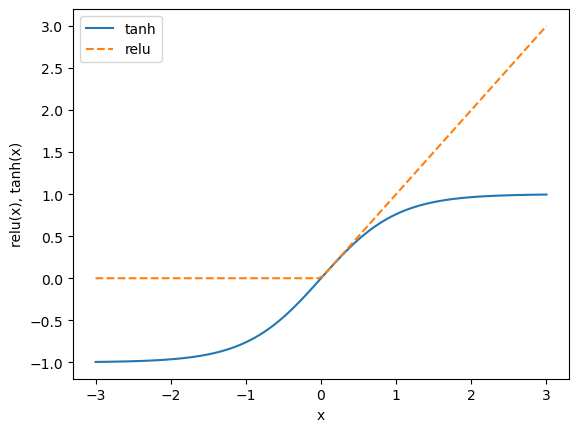

In [12]:
line = np.linspace(-3,3,100)
plt.plot(line, np.tanh(line), label='tanh')
plt.plot(line, np.maximum(line,0), linestyle='--', label='relu')
plt.legend(loc='best')
plt.xlabel('x')
plt.ylabel('relu(x), tanh(x)')

#### <U>*신경망 튜닝*</U>
- **신경망의 매개변수를 조정하는 일반적인 방법은 먼저 충분히 과대적합되어서 문제를 해결할만한 큰 모델을 만들고, 이후 훈련 데이터가 충분히 학습될 수 있다고 생각될 때 신경망 구조를 줄이거나 규제 강화를 위해 alpha 값을 증가시켜 일반화 성능을 향상**

Text(0, 0.5, 'Feature 1')

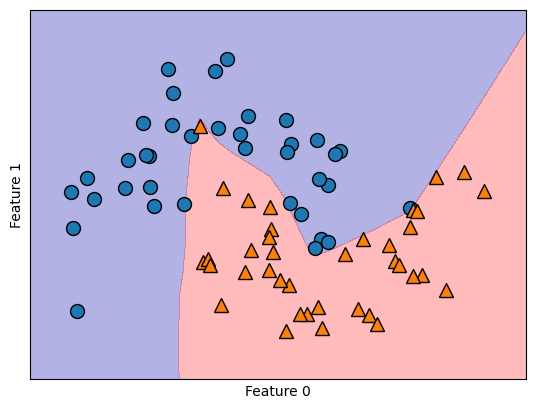

In [13]:
# two_moons 데이터셋에 분류를 위한 다층 퍼셉트론(MLP) 구현

from sklearn.neural_network import MLPClassifier
from sklearn.datasets import make_moons

X, y = make_moons(n_samples=100, noise=0.25, random_state=3)

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

# 은닉 유닛 100개 사용이 기본값, hidden_layer_sizes=[10]와 같이 매개변수 조절함
mlp = MLPClassifier(solver='lbfgs', random_state=0).fit(X_train, y_train)
mglearn.plots.plot_2d_separator(mlp, X_train, fill=True, alpha=0.3)
mglearn.discrete_scatter(X_train[:,0], X_train[:,1], y_train)
plt.xlabel('Feature 0')
plt.ylabel('Feature 1')

- 은닉 유닛 개수가 작아지면 결정 경계가 조금 더 날카로워 짐
- 기본 비선형 함수는 'relu'임
- **모델의 복잡도가 올라가면 매끄러운 결정 경계 달성 가능**

- **<U>신경망 모델의 복잡도 조절</U>**
> - **은닉 유닛 조절 : hidden_layer_sizes = [1000]**
> - **은닉 층 개수 조절 : hidden_layer_sizes = [100, 100]**
> - **활성화 함수 조절** : 'relu(기본값)', 'tanh', 'logistic', 'identify'
> - **L2 규제(alpha) 사용, 기본값은 0.0001로 거의 규제하지 않음, 값을 올릴 경우 규제가 강해지므로 복잡도 감소**
> - **Dropout 사용** : **은닉층 유닛의 일부를 랜덤하게 작동시키지 않음으로써** 마치 서로 다른 많은 신경망을 앙상블시키는 것 같은 효과를 내어 과적합 방지, scikit-learn에서는 지원하지 않음
> - **조기 종료 사용** : **solver가 sgd 또는 adam일 때 early_stopping을 True로 설정하면 연속된 검증 점수가 tol 값만큼 향상되지 않을 경우 반복을 자동으로 조기 종료시킴**, 조기 종료하기 위해 검증 점수가 향상되지 않는 반복 횟수의 기준 설정은 n_iter_no_change 매개변수, 검증 데이터의 비율은 validation_fraction 매개변수에서 조절

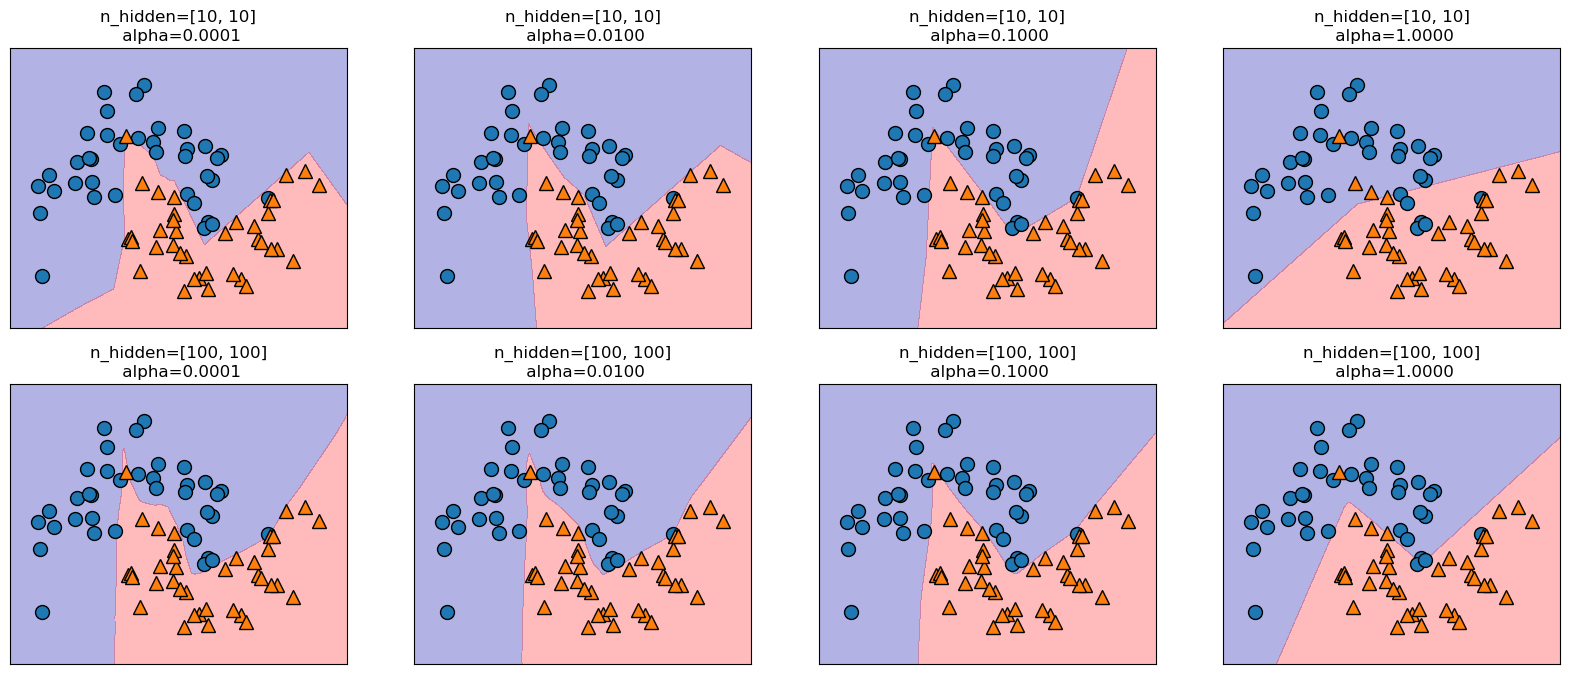

In [14]:
# 은닉층 내 유닛수, 은닉층 개수, 활성화함수, 규제값 변경 영향
fig, axes = plt.subplots(2,4, figsize=(20,8))
for axx, n_hidden_nodes in zip(axes, [10,100]):
    for ax, alpha in zip(axx, [0.0001, 0.01, 0.1, 1]):
        mlp = MLPClassifier(solver='lbfgs', random_state=0, max_iter=1000,
                           hidden_layer_sizes=[n_hidden_nodes, n_hidden_nodes], alpha=alpha)
        mlp.fit(X_train, y_train)
        mglearn.plots.plot_2d_separator(mlp, X_train, fill=True, alpha=0.3, ax=ax)
        mglearn.discrete_scatter(X_train[:,0], X_train[:,1], y_train, ax=ax)
        ax.set_title('n_hidden=[{}, {}]\n alpha={:.4f}'.format(n_hidden_nodes, n_hidden_nodes, alpha))

In [15]:
# 유방암 데이터셋에 MLPClassifier를 적용, 매개변수는 기본값 사용
from sklearn.datasets import load_breast_cancer
cancer = load_breast_cancer()

print('유방암 데이터의 특성별 최댓값:\n', cancer.data.max(axis=0))

유방암 데이터의 특성별 최댓값:
 [2.811e+01 3.928e+01 1.885e+02 2.501e+03 1.634e-01 3.454e-01 4.268e-01
 2.012e-01 3.040e-01 9.744e-02 2.873e+00 4.885e+00 2.198e+01 5.422e+02
 3.113e-02 1.354e-01 3.960e-01 5.279e-02 7.895e-02 2.984e-02 3.604e+01
 4.954e+01 2.512e+02 4.254e+03 2.226e-01 1.058e+00 1.252e+00 2.910e-01
 6.638e-01 2.075e-01]


In [16]:
from sklearn.neural_network import MLPClassifier
X_train, X_test, y_train, y_test = train_test_split(cancer.data, cancer.target, random_state=0)
mlp = MLPClassifier(random_state=42)
mlp.fit(X_train, y_train)

print('훈련 세트 정확도: {:.2f}'.format(mlp.score(X_train, y_train)))
print('테스트 세트 정확도: {:.2f}'.format(mlp.score(X_test, y_test)))

훈련 세트 정확도: 0.94
테스트 세트 정확도: 0.92


In [17]:
# 위 예시에서 모든 입력 특성을 평균 0, 분산 1인 데이터로 변환(z-score, Standardscaler)하여 검토
# 훈련 세트 각 특성의 평균을 계산
mean_on_train = X_train.mean(axis=0)
# 훈련 세트 각 특성의 표준 편차를 계산
std_on_train = X_train.std(axis=0)

# 데이터에서 평균을 빼고 표준편차로 나누면 평균 0, 표준편차 1인 데이터로 변환 (z-score or standard score)
X_train_scaled = (X_train - mean_on_train) / std_on_train
# (훈련 데이터의 평균과 표준편차를 이용해) 테스트 세트에도 동일한 변환 적용
X_test_scaled = (X_test - mean_on_train) / std_on_train

mlp = MLPClassifier(random_state=0, max_iter=1000) #반복횟수 조절로 오류 출력 해결
mlp.fit(X_train_scaled, y_train)

print('훈련 세트 정확도: {:.2f}'.format(mlp.score(X_train_scaled, y_train)))
print('테스트 세트 정확도: {:.2f}'.format(mlp.score(X_test_scaled, y_test)))

훈련 세트 정확도: 1.00
테스트 세트 정확도: 0.97


In [18]:
# 일반화 성능을 올리기 위해 모델의 복잡도를 낮춤(규제 적용 : alpha 0.001 -> 1)
mlp = MLPClassifier(max_iter=1000, alpha=1, random_state=0)
mlp.fit(X_train_scaled, y_train)

print('훈련 세트 정확도: {:.2f}'.format(mlp.score(X_train_scaled, y_train)))
print('테스트 세트 정확도: {:.2f}'.format(mlp.score(X_test_scaled, y_test)))

훈련 세트 정확도: 0.99
테스트 세트 정확도: 0.97


- **<U>신경망 모델 분석</U>**
> - 신경망이 어떻게 학습하는지 분석할 수 있지만 선형 모델이나 트리 모델보다는 훨씬 까다로움
> - **모델의 가중치를 확인하여 특성 중요도 파악 가능**
> - ***mlp.coef_[0]은* 입력과 은닉층 사이의 가중치가 저장**, ***mlp.coef_[1]은* 은닉층과 출력 사이의 가중치가 저장**

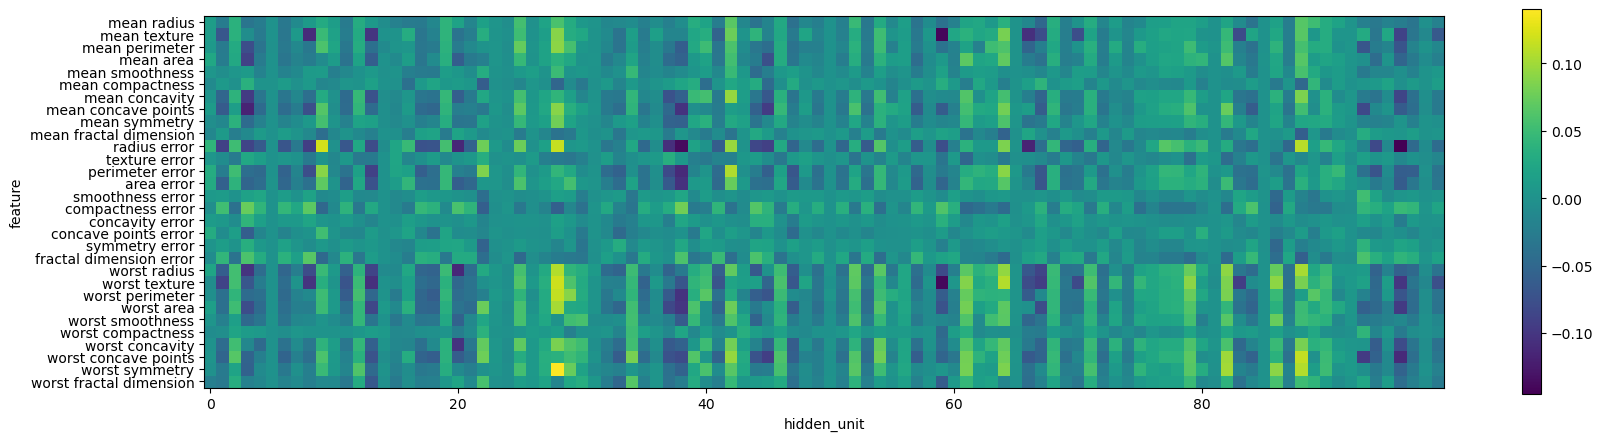

In [19]:
plt.figure(figsize=(20,5))
plt.imshow(mlp.coefs_[0], interpolation='none', cmap='viridis')
plt.yticks(range(30), cancer.feature_names)
plt.xlabel('hidden_unit')
plt.ylabel('feature')
plt.colorbar()